# Atelier Préparation de Données Textuelles

## Contexte

Une entreprise souhaite développer un système capable de classer automatiquement des avis clients afin d'identifier leur sentiment. Les avis proviennent de plusieurs sources : site web, application mobile, formulaire de satisfaction, réseaux sociaux et service client.

Les données collectées sont cependant de qualité variable : textes vides, doublons, fautes de frappe, majuscules/minuscules, caractères spéciaux, emojis, URLs, mentions, répétitions de caractères, textes très courts ou très longs, plusieurs catégories de sentiment et quelques valeurs manquantes.

Avant de construire un modèle de Machine Learning ou de Deep Learning, les apprenants doivent donc construire un pipeline complet de préparation des données textuelles.

# Partie 1 – Exploration du corpus

In [1]:
# Question 1 : Charger les données CSV
import pandas as pd

df = pd.read_csv("../data/smart_reviews_raw.csv")

In [2]:
# Question 2 : Nombre d'avis dans le dataset
df.shape[0]

1200

In [3]:
# Question 3 : Nombre de colonnes du dataset
df.shape[1]

8

In [4]:
# Question 4 : Type de chaque colonne
df.dtypes

id_avis      object
date         object
source       object
produit      object
texte        object
sentiment    object
note          int64
langue       object
dtype: object

In [5]:
# Question 5 : Valeurs manquantes par colonne
df.isna().sum()

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

In [ ]:
# Question 6 : Identifier quelques types de texte en affichant par exemple

In [6]:
# Question 6.a : Exemple de texte normal
df[df['texte'].str.len() > 20]['texte'].iloc[0]

'Très  bonne  expérience,  simple  et  efficace.'

In [7]:
# Question 6.b : Exemple de texte vide
df[df['texte'].isna() | (df['texte'].str.strip() == '')]

,id_avis,date,source,produit,texte,sentiment,note,langue
46,AV0047,2026-02-24,réseaux_sociaux,SmartWatch Pro,NaN,positif,4,fr
108,AV0109,2026-01-24,email,SmartPhone Y,NaN,positif,5,fr
310,AV0311,2026-02-13,réseaux_sociaux,Ordinateur NovaBook,NaN,positif,5,fr
640,AV0641,2026-08-25,réseaux_sociaux,SmartPhone Y,NaN,positif,5,fr
781,AV0782,2026-05-21,email,SmartPhone Y,NaN,neutre,4,fr
951,AV0952,2026-06-11,web,Ordinateur NovaBook,,positif,4,fr


In [8]:
# Question 6.c : Exemple de texte contenant une URL
df[df['texte'].str.contains('http', na=False)]['texte'].iloc[0]

'Produit parfait, rien à signaler. https://example.com/commande/17'

In [9]:
# Question 6.d : Exemple de texte contenant une mention
df[df['texte'].str.contains('@', na=False)]['texte'].iloc[0]

'@client Livraison rapide et produit conforme à mes attentes.'

In [10]:
# Question 6.e : Exemple de texte contenant un hashtag
df[df['texte'].str.contains('#', na=False)]['texte'].iloc[0]

'Très satisfait de mon achat 👍 #avis'

In [11]:
# Question 6.f : Exemple de texte contenant des emojis
df[df['texte'].str.contains('👍|😀|😍|👎|😡|❤️|🙂|😞', na=False, regex=True)]['texte'].iloc[0]

'Très satisfait de mon achat 👍 #avis'

In [12]:
# Question 6.g : Exemple de texte avec beaucoup de ponctuation
import re

df[df['texte'].apply(lambda t: len(re.findall(r'[!?.]{2,}', str(t))) > 0 if pd.notna(t) else False)]['texte'].iloc[0]

'Produit excellent, je suis très satisfait. !!!'

In [14]:
# Question 6.h : Exemple de texte en majuscules
# isupper() vérifie que la chaîne ne contient aucune lettre minuscule (et au moins une lettre)
df[df['texte'].apply(lambda t: str(t).isupper() if pd.notna(t) else False)]['texte'].iloc[0]

"LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE."

In [16]:
# Question 6.i (affinée) : Exemple de texte avec répétition de lettres
# [a-zA-ZàâäéèêëïîôöùûüÿçÀÂÄÉÈÊËÏÎÔÖÙÛÜŸÇ] cible uniquement les lettres (accents inclus), pas la ponctuation
df[df['texte'].apply(lambda t: len(re.findall(r'([a-zA-ZàâäéèêëïîôöùûüÿçÀÂÄÉÈÊËÏÎÔÖÙÛÜŸÇ])\1{2,}', str(t))) > 0 if pd.notna(t) else False)]['texte'].iloc[0]

'Produit excellent, je suis trèèès satisfait.'

In [ ]:
# Question 7 : Création de la colonne longueur + statistiques
df['longueur'] = df['texte'].str.len()

df['longueur'].describe()

count    1195.000000
mean       49.168201
std        22.171465
min         2.000000
25%        37.000000
50%        48.000000
75%        56.000000
max       636.000000
Name: longueur, dtype: float64

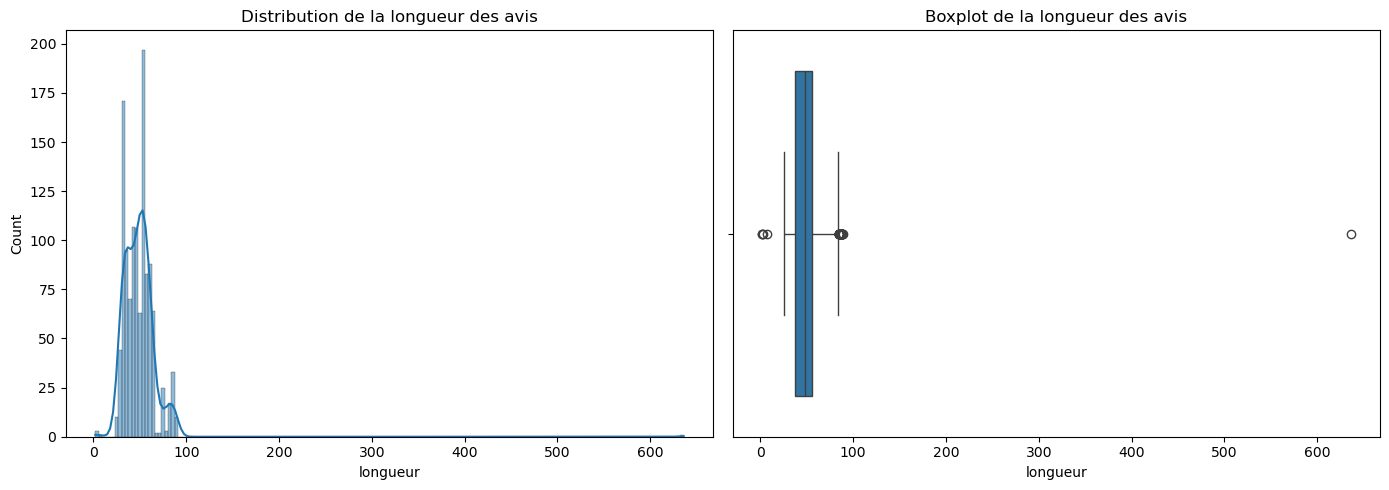

In [22]:
# Question 8 : Visualisation de la distribution de la longueur des avis
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['longueur'], kde=True, ax=axes[0])
axes[0].set_title('Distribution de la longueur des avis')

sns.boxplot(x=df['longueur'], ax=axes[1])
axes[1].set_title('Boxplot de la longueur des avis')

plt.tight_layout()
plt.show()

**Question 8.a : Existe-t-il des textes anormalement longs ?**

Oui, très clairement. L'histogramme montre que la quasi-totalité des textes se concentre entre 0 et 100 caractères, mais le boxplot révèle un point isolé loin à droite, autour de 630-640 caractères — cohérent avec le max de 636 observé en Q7. C'est un texte extrême, complètement déconnecté du reste de la distribution.

**Question 8.b : Existe-t-il beaucoup de textes très courts ?**

Oui — le boxplot montre plusieurs points isolés à gauche, proches de 0-20 caractères, et l'histogramme confirme une petite barre non négligeable près de 0. Ce n'est pas un cas isolé unique comme le texte long (Q8.a), mais un petit groupe de textes anormalement courts (proches du minimum de 2 caractères vu en Q7) — potentiellement des avis peu informatifs ou tronqués.

In [23]:
# Question 9 : Détecter les textes vides
textes_vides = df[df['texte'].isna() | (df['texte'].str.strip() == '')]

print("Nombre de textes vides :", len(textes_vides))
textes_vides

Nombre de textes vides : 6


,id_avis,date,source,produit,texte,sentiment,note,langue,longueur
46,AV0047,2026-02-24,réseaux_sociaux,SmartWatch Pro,NaN,positif,4,fr,NaN
108,AV0109,2026-01-24,email,SmartPhone Y,NaN,positif,5,fr,NaN
310,AV0311,2026-02-13,réseaux_sociaux,Ordinateur NovaBook,NaN,positif,5,fr,NaN
640,AV0641,2026-08-25,réseaux_sociaux,SmartPhone Y,NaN,positif,5,fr,NaN
781,AV0782,2026-05-21,email,SmartPhone Y,NaN,neutre,4,fr,NaN
951,AV0952,2026-06-11,web,Ordinateur NovaBook,,positif,4,fr,3.0


In [26]:
# Question 10 (re-corrigée) : exclure aussi les textes vides (pas seulement NaN)
df_texte_valide = df[df['texte'].notna() & (df['texte'].str.strip() != '')]
doublons_texte = df_texte_valide[df_texte_valide.duplicated(subset='texte', keep=False)].sort_values('texte')

print("Nombre de lignes impliquées dans un doublon de texte :", len(doublons_texte))
print("Nombre de textes uniques dupliqués :", doublons_texte['texte'].nunique())
doublons_texte[['id_avis', 'texte', 'source', 'produit']]

Nombre de lignes impliquées dans un doublon de texte : 1031
Nombre de textes uniques dupliqués : 154


,id_avis,texte,source,produit
312,AV0313,@client Excellent rapport qualité-prix.,mobile,Écouteurs AirSound
419,AV0420,@client Excellent rapport qualité-prix.,sav,Ordinateur NovaBook
1099,AV1100,@client Excellent rapport qualité-prix.,email,Tablette TabPlus
45,AV0046,@client Excellent rapport qualité-prix.,web,SmartPhone X
466,AV0467,@client Excellent rapport qualité-prix.,mobile,Ordinateur NovaBook
...,...,...,...,...
198,AV0199,Très satisfait de mon achat 👍 😊,web,Tablette TabPlus
5,AV0006,Très satisfait de mon achat 👍 😊,web,Ordinateur NovaBook
968,AV0969,Très satisfait de mon achat 👍 😊,email,SmartWatch Pro
745,AV0746,Très satisfait de mon achat 👍 😊,mobile,Écouteurs AirSound


**Question 10 : Doublons sur le texte **

Après exclusion des valeurs manquantes et des textes vides, 1031 avis sur 1194 textes valides (~86%) partagent leur texte avec au moins un autre avis, répartis sur 154 textes uniques dupliqués (moyenne ~6-7 répétitions par texte).

Note : il s'agit de doublons **sur le contenu textuel uniquement** (pas de lignes strictement identiques sur toutes les colonnes) — les avis concernés ont des `id_avis`, sources et produits différents. Ce taux élevé suggère un corpus généré à partir d'un nombre limité de phrases-types réutilisées, plutôt que des doublons au sens d'une erreur de collecte. Conformément à la consigne, ils seront traités comme doublons et supprimés en Partie 2 (un seul exemplaire conservé par texte identique).

In [27]:
# Question 11 : Équilibre des classes (sentiment)
df['sentiment'].value_counts()

sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64

In [28]:
print("\nProportions (%) :")
(df['sentiment'].value_counts(normalize=True) * 100).round(2)


Proportions (%) :


sentiment
positif    64.67
neutre     20.50
negatif    14.83
Name: proportion, dtype: float64

**Question 11 : Les classes sont-elles équilibrées ?**

Non, les classes sont clairement déséquilibrées :
- `positif` : 776 avis (64.67%)
- `neutre` : 246 avis (20.50%)
- `negatif` : 178 avis (14.83%)

Le ratio entre la classe la plus représentée et la moins représentée est d'environ 4.4:1, un déséquilibre modéré à significatif qui devra être pris en compte lors du découpage train/test (stratification) et du choix des métriques d'évaluation.

**Question 12 : Quelle est la classe majoritaire ?**

La classe majoritaire est `positif`, avec 776 avis, soit 64.67% du dataset.

**Question 13 : Métriques de classification à envisager**

L'accuracy seule serait trompeuse ici : un modèle qui prédirait systématiquement `positif` (la classe majoritaire) obtiendrait déjà ~64.67% d'accuracy sans avoir rien appris, alors qu'il échouerait totalement sur `neutre` et `negatif`.

Métriques plus adaptées à privilégier :
- **Precision, Recall et F1-score par classe**, pour évaluer la performance sur chaque sentiment individuellement (notamment `negatif`, la classe minoritaire, souvent la plus critique à détecter dans un contexte de satisfaction client)
- **F1-score macro** (moyenne non pondérée entre les 3 classes), qui ne favorise pas artificiellement la classe majoritaire
- **Matrice de confusion**, pour visualiser les confusions entre classes (ex: `neutre` mal classé en `positif`)